In [1]:
# (Code skeleton written with help from Perplexity, and some manual adjustments)
# Cell1: load and preprocess data

import pandas as pd
import numpy as np
import re
from nltk.tokenize import sent_tokenize
import nltk
import matplotlib.pyplot as plt

rev = pd.read_csv('reviewer.csv')
rev = rev.copy()
rev['role'] = rev['Victim/Abuser/Third'].map({'A':'Abuser','V':'Victim','T':'Third'})
rev['body'] = rev['body'].fillna('').astype(str)
rev = rev[rev['role'].notna()].reset_index(drop=True)

print('reviewer shape:', rev.shape)
print(rev['role'].value_counts())

reviewer shape: (403, 12)
role
Abuser    223
Victim    121
Third      59
Name: count, dtype: int64


In [2]:
# Cell2: load NRC-VAD lexicon
import pandas as pd
from pathlib import Path

lex = None
for p in ['NRC-VAD-Lexicon-v2.1.txt']:
    if Path(p).exists():
        sep = '\t' if p.endswith(('.txt')) else ','
        lex = pd.read_csv(p, sep=sep)
        print('loaded lexicon from', p)
        break

if lex is None:
    raise FileNotFoundError('Please download NRC-VAD-Lexicon and place it in the notebook folder.')

print(lex.columns.tolist())
display(lex.head())

cols = {c.lower(): c for c in lex.columns}
word_col = cols.get('word', lex.columns[0])
val_col = cols.get('valence')
ar_col = cols.get('arousal')
dom_col = cols.get('dominance')

lex = lex[[word_col, val_col, ar_col, dom_col]].copy()
lex.columns = ['word', 'valence', 'arousal', 'dominance']
lex['word'] = lex['word'].astype(str).str.lower()
print(lex.shape)

loaded lexicon from NRC-VAD-Lexicon-v2.1.txt
['term', 'valence', 'arousal', 'dominance']


,term,valence,arousal,dominance
0,a battery,0.134,-0.298,-0.096
1,a bit,-0.096,-0.264,-0.214
2,a bunch,0.088,-0.350,-0.068
3,a cappella,0.134,-0.116,-0.200
4,a couple,0.266,-0.110,0.090


(54801, 4)


In [3]:
# Cell3: extract relevant sentences
kw_pat = re.compile(r'\b(?:spy|stalk|stealth)\w*\b', flags=re.I)
rows = []

for _, r in rev.iterrows():
    for s in sent_tokenize(r['body']):
        if kw_pat.search(s):
            rows.append({'role': r['role'], 'sentence': s})

kw_df = pd.DataFrame(rows)
print('keyword sentences:', kw_df.shape)
print(kw_df['role'].value_counts())
display(kw_df.head(10))

keyword sentences: (421, 2)
role
Abuser    224
Victim    136
Third      61
Name: count, dtype: int64


,role,sentence
0,Abuser,I love that you can take a picture and am cons...
1,Third,This is also good to spy on someone.
2,Abuser,i can spy on my child whenever i want its amaz...
3,Abuser,Great app for families keeping track of their ...
4,Abuser,Another way of spying on people.
5,Abuser,Now that I can spy on my wife I'll always know...
6,Abuser,Now that I can spy on my wife I&#39;ll always ...
7,Abuser,Now I have to find another app or just pay for...
8,Third,I'm only a kid just want to spy on my sister t...
9,Abuser,Well me and my friends are insane so we mostly...


In [4]:
# Cell4: extract adjectives with NLTK POS tagger
import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize

# if needed, run once in PowerShell:
# python -m nltk.downloader punkt
# python -m nltk.downloader punkt_tab
# python -m nltk.downloader averaged_perceptron_tagger
# python -m nltk.downloader averaged_perceptron_tagger_eng

# quick check for resources
for pkg in ['tokenizers/punkt', 'tokenizers/punkt_tab', 'taggers/averaged_perceptron_tagger', 'taggers/averaged_perceptron_tagger_eng']:
    try:
        nltk.data.find(pkg)
        print('found', pkg)
    except LookupError:
        print('missing', pkg)

# extract adjectives
def extract_adjs(text):
    return [w.lower() for w, t in pos_tag(word_tokenize(text)) if t.startswith('JJ')]

kw_df['adjectives'] = kw_df['sentence'].apply(extract_adjs)
kw_df['adj_text'] = kw_df['adjectives'].apply(lambda xs: ', '.join(xs))
display(kw_df[['role','sentence','adjectives']].head(10))

found tokenizers/punkt
found tokenizers/punkt_tab
found taggers/averaged_perceptron_tagger
found taggers/averaged_perceptron_tagger_eng


,role,sentence,adjectives
0,Abuser,I love that you can take a picture and am cons...,[]
1,Third,This is also good to spy on someone.,[good]
2,Abuser,i can spy on my child whenever i want its amaz...,[]
3,Abuser,Great app for families keeping track of their ...,[creepy]
4,Abuser,Another way of spying on people.,[]
5,Abuser,Now that I can spy on my wife I'll always know...,[]
6,Abuser,Now that I can spy on my wife I&#39;ll always ...,[s]
7,Abuser,Now I have to find another app or just pay for...,"[sure, ’, m]"
8,Third,I'm only a kid just want to spy on my sister t...,"[sister, good]"
9,Abuser,Well me and my friends are insane so we mostly...,"[insane, other]"


In [5]:
# Cell5: Match adjectives to NRC-VAD and compute averages by role
vad = kw_df[['role', 'adjectives']].explode('adjectives').dropna().rename(columns={'adjectives': 'word'})
vad['word'] = vad['word'].astype(str).str.lower()
vad = vad.merge(lex, on='word', how='inner')

print('matched adjective tokens:', vad.shape)
display(vad.head(10))

role_counts = vad.groupby('role').size().rename('matched_tokens').reset_index()
role_means = vad.groupby('role')[['valence', 'arousal', 'dominance']].mean().round(3).reset_index()
role_stats = vad.groupby('role')[['valence', 'arousal', 'dominance']].agg(['count', 'mean']).round(3)

print(role_counts)
display(role_means)
display(role_stats)

# save outputs
out = Path('output')
out.mkdir(exist_ok=True)
vad.to_csv(out/'task1_matched_adjectives.csv', index=False)
role_means.to_csv(out/'task1_role_means.csv', index=False)
role_stats.to_csv(out/'task1_role_stats.csv')

matched adjective tokens: (393, 5)


,role,word,valence,arousal,dominance
0,Third,good,0.876,-0.264,0.068
1,Abuser,creepy,-0.750,0.722,-0.254
2,Abuser,sure,0.448,-0.460,0.586
3,Third,sister,0.832,-0.352,0.124
4,Third,good,0.876,-0.264,0.068
5,Abuser,insane,-0.704,0.340,-0.470
6,Abuser,other,-0.056,-0.540,-0.482
7,Victim,worst,-0.834,-0.070,-0.548
8,Abuser,useful,0.526,-0.178,0.452
9,Victim,horrible,-0.858,0.714,-0.204


     role  matched_tokens
0  Abuser             190
1   Third              71
2  Victim             132


,role,valence,arousal,dominance
0,Abuser,0.380,-0.034,0.189
1,Third,0.243,-0.073,0.061
2,Victim,0.131,-0.007,0.065


valence        arousal        dominance       
         count   mean   count   mean     count   mean
role                                                 
Abuser     190  0.380     190 -0.034       190  0.189
Third       71  0.243      71 -0.073        71  0.061
Victim     132  0.131     132 -0.007       132  0.065

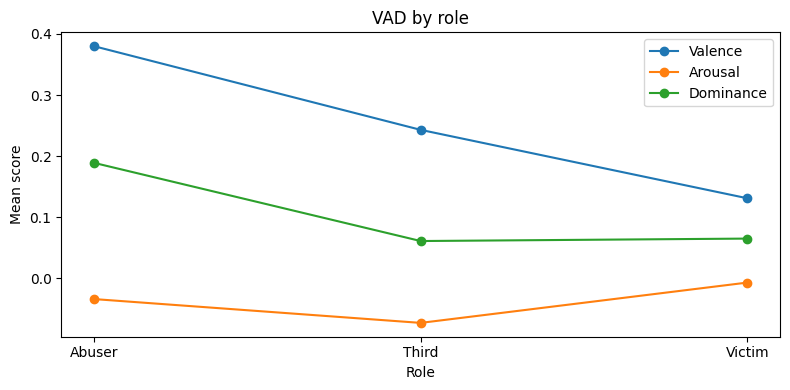

In [6]:
# Cell6: Visualization
import matplotlib.pyplot as plt

plot_df = role_means.melt(id_vars='role', var_name='dimension', value_name='score')
fig, ax = plt.subplots(figsize=(8, 4))
for dim in ['valence', 'arousal', 'dominance']:
    sub = plot_df[plot_df['dimension'] == dim]
    ax.plot(sub['role'], sub['score'], marker='o', label=dim.title())

ax.set_xlabel('Role')
ax.set_ylabel('Mean score')
ax.set_title('VAD by role')
ax.legend()
plt.tight_layout()

out = Path('output')
out.mkdir(exist_ok=True)
plt.savefig(out/'task1_vad_by_role.png', dpi=200)
plt.show()